In [1]:
# Cell 1 — Imports and config
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

BASE       = '/scratch.global/ocon0444/peat_modeling'
MDL_DIR    = os.path.join(BASE, '03_models/exp421')
RES_DIR    = os.path.join(BASE, '05_results/exp421')
CSV_PATH   = os.path.join(BASE, '00_data/processed/organic_composition_features_extracted.csv')
EXP410_DIR = os.path.join(BASE, '03_models/exp410')
CATALOG    = os.path.join(BASE, 'MODEL_CATALOG.csv')

TARGETS     = ['Fibric_pct', 'Hemic_pct', 'Sapric_pct']
COLORS      = {'Fibric_pct': '#3498db', 'Hemic_pct': '#e67e22', 'Sapric_pct': '#8e44ad'}
PROB_THRESH = 0.33
N_FOLDS     = 5

EXCLUDE_ALWAYS = [
    'point_id','source','flag','lat','lon',
    'total_cm_in_range','coverage_weight','pct_sum',
    'Fibric_pct','Hemic_pct','Sapric_pct','Mineral_pct','Unknown_pct',
    's2_spring_TCB','s2_spring_TCG','s2_spring_TCW',
    's2_summer_TCB','s2_summer_TCG','s2_summer_TCW',
    'dist_from_waterbody_edge_10m',
    'gNATSGO_MN_26915','npc_peatland_indicator_10m',
    'histosols_10m_snapped','histosols_10m',
    'MN_organic_soils_classified_FIXED_snapped',
    'MN_organic_soils_classified_FIXED',
    'MN_ANY_organic_component_snapped',
    'MN_ANY_organic_component',
]
ONEHOT_PREFIXES = ['quaternary_geology_', 'pennockLandformClass_', 'geomorphons_']
print('Config loaded.')

Config loaded.


In [2]:
# Cell 2 — Load feature list and models
with open(os.path.join(MDL_DIR, 'feature_list.json')) as f:
    meta = json.load(f)

feature_cols = meta['features']
print(f"exp421 — {len(feature_cols)} features, {meta['n_samples']} samples")
print(f"Mask: {meta['mask']}")
print(f"Coverage weighted: {meta['coverage_weighted']}")
print()
print('Per-target results from training:')
for t, r in meta['results'].items():
    print(f"  {t}: R²={r['mean_r2']}  MAE={r['mean_mae']}%  RMSE={r['mean_rmse']}%")

models = {}
for target in TARGETS:
    stub = target.replace('_pct','').lower()
    models[target] = [
        pickle.load(open(os.path.join(MDL_DIR, f'model_{stub}_fold_{i}.pkl'),'rb'))
        for i in range(N_FOLDS)
    ]
print('Models loaded.')

exp421 — 125 features, 10679 samples
Mask: exp410_peat_prob >= 0.33
Coverage weighted: True

Per-target results from training:
  Fibric_pct: R²=0.353  MAE=17.15%  RMSE=26.15%
  Hemic_pct: R²=0.3406  MAE=27.22%  RMSE=34.64%
  Sapric_pct: R²=0.5762  MAE=14.13%  RMSE=24.13%
Models loaded.


In [3]:
# Cell 3 — Load and prep data (must match training script exactly)
df_all = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Full CSV: {df_all.shape}')

# Derive NWI columns exp410 was trained with
df_all['mn_nwi_binary'] = (
    (df_all['mn_nwi_cowardin_10m'] == 1) | (df_all['mn_nwi_cowardin_10m'] == 2)
).astype(int)
df_all['mn_nwi_cowardin_0'] = (df_all['mn_nwi_cowardin_10m'] == 0).astype(int)

# exp410 mask
with open(os.path.join(EXP410_DIR, 'feature_list.json')) as f:
    exp410_feats = json.load(f)['features']
exp410_models = [
    pickle.load(open(os.path.join(EXP410_DIR, f'model_fold_{i}.pkl'),'rb'))
    for i in range(N_FOLDS)
]
exp410_cols = [c for c in exp410_feats if c in df_all.columns]
X_mask = df_all[exp410_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
peat_prob = np.stack([m.predict_proba(X_mask)[:,1] for m in exp410_models]).mean(axis=0)
df_all['exp410_peat_prob'] = peat_prob

# Apply same filters as training script
df = df_all[df_all['exp410_peat_prob'] >= PROB_THRESH].copy().reset_index(drop=True)
df = df.dropna(subset=TARGETS).reset_index(drop=True)
df = df[df['minnesota_dem_10m'].notna()].reset_index(drop=True)

X = df[feature_cols].apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

print(f'Training-equivalent rows: {len(df):,}')
print(f'Feature matrix: {X.shape}')

Full CSV: (18041, 158)
Training-equivalent rows: 10,679
Feature matrix: (10679, 125)


In [4]:
# Cell 4 — CV results summary table
print(f"{'Target':<15} {'R²':>8} {'R² std':>8} {'MAE (%)':>10} {'RMSE (%)':>10}")
print('-' * 55)
for target in TARGETS:
    stub = target.replace('_pct','').lower()
    cv = pd.read_csv(os.path.join(MDL_DIR, f'cv_results_{stub}.csv'))
    print(f"{target:<15} {cv['r2'].mean():>8.4f} {cv['r2'].std():>8.4f} "
          f"{cv['mae'].mean():>10.2f} {cv['rmse'].mean():>10.2f}")
print()
for target in TARGETS:
    stub = target.replace('_pct','').lower()
    cv = pd.read_csv(os.path.join(MDL_DIR, f'cv_results_{stub}.csv'))
    print(f'{target}:')
    print(cv.to_string(index=False))
    print()

Target                R²   R² std    MAE (%)   RMSE (%)
-------------------------------------------------------
Fibric_pct        0.3530   0.0266      17.15      26.15
Hemic_pct         0.3406   0.0168      27.22      34.64
Sapric_pct        0.5762   0.0233      14.13      24.13

Fibric_pct:
 fold       r2       mae      rmse
    0 0.314153 17.913399 27.286355
    1 0.368415 17.479013 26.410400
    2 0.385309 16.362167 25.039656
    3 0.349234 17.013904 26.178866
    4 0.347713 16.990668 25.829766

Hemic_pct:
 fold       r2       mae      rmse
    0 0.340590 27.344298 34.784907
    1 0.313742 28.113042 35.305228
    2 0.359107 26.364326 33.711205
    3 0.341365 27.265270 34.784172
    4 0.348430 26.989022 34.621199

Sapric_pct:
 fold       r2       mae      rmse
    0 0.597559 13.570895 23.136353
    1 0.539440 14.607913 25.190276
    2 0.569279 14.217422 24.476437
    3 0.582269 14.140128 24.057336
    4 0.592688 14.097587 23.782396



In [5]:
# Cell 5 — Rebuild OOF predictions using same KFold seed as training
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
oof_preds = {t: np.zeros(len(df)) for t in TARGETS}

for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
    for target in TARGETS:
        pred = models[target][fold].predict(X.iloc[va_idx])
        oof_preds[target][va_idx] = np.clip(pred, 0, 100)

print('OOF predictions rebuilt.')
for target in TARGETS:
    y_true = df[target].values
    y_pred = oof_preds[target]
    r2 = r2_score(y_true, y_pred)
    print(f'  {target}: R²={r2:.4f}  NaN in y_true={np.isnan(y_true).sum()}  NaN in y_pred={np.isnan(y_pred).sum()}')

OOF predictions rebuilt.
  Fibric_pct: R²=0.3528  NaN in y_true=0  NaN in y_pred=0
  Hemic_pct: R²=0.3407  NaN in y_true=0  NaN in y_pred=0
  Sapric_pct: R²=0.5762  NaN in y_true=0  NaN in y_pred=0


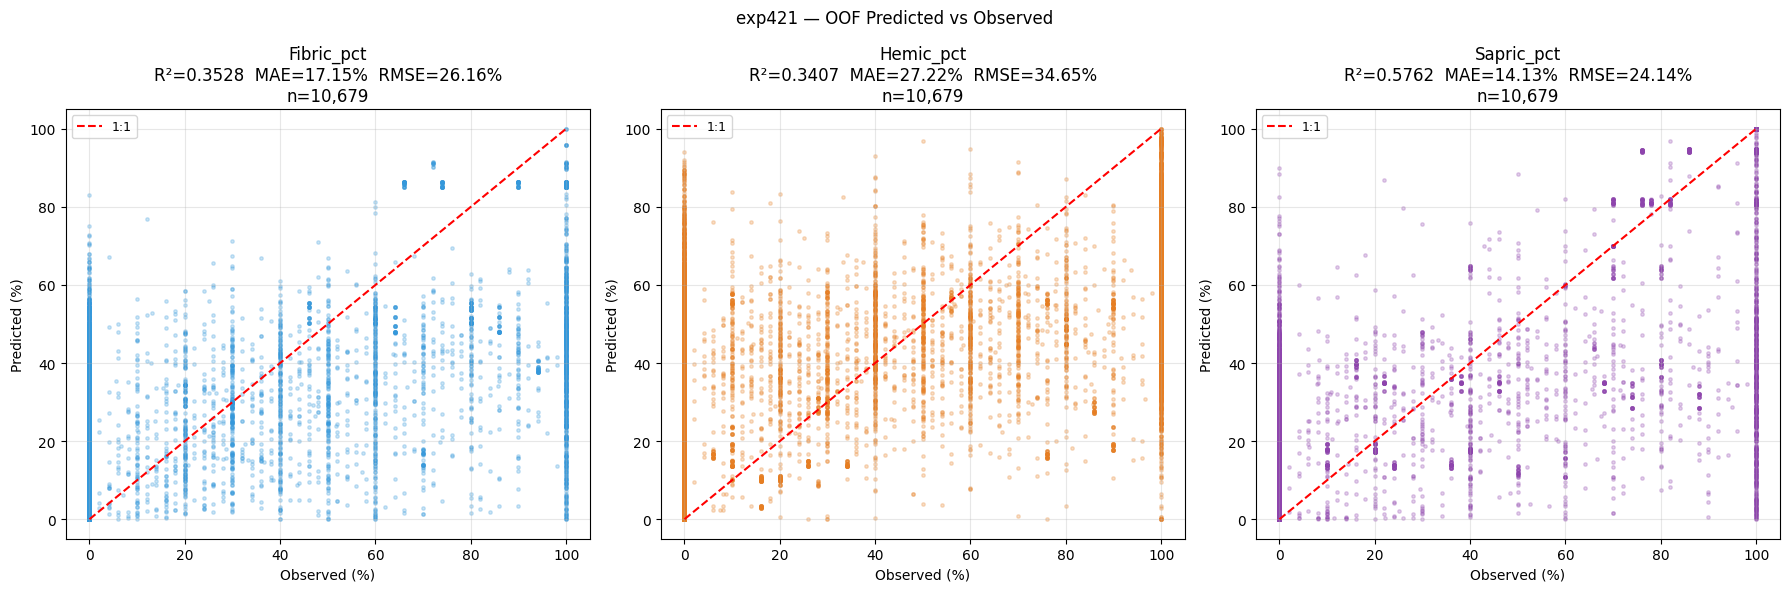

In [6]:
# Cell 6 — Predicted vs observed scatter
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, target in zip(axes, TARGETS):
    y_true = df[target].values
    y_pred = oof_preds[target]
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.scatter(y_true, y_pred, alpha=0.25, s=6, color=COLORS[target])
    lim = max(y_true.max(), y_pred.max())
    ax.plot([0,lim],[0,lim],'r--',lw=1.5,label='1:1')
    ax.set_xlabel('Observed (%)')
    ax.set_ylabel('Predicted (%)')
    ax.set_title(f"{target}\nR²={r2:.4f}  MAE={mae:.2f}%  RMSE={rmse:.2f}%\nn={len(y_true):,}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('exp421 — OOF Predicted vs Observed', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'predicted_vs_observed.png'), dpi=150, bbox_inches='tight')
plt.show()

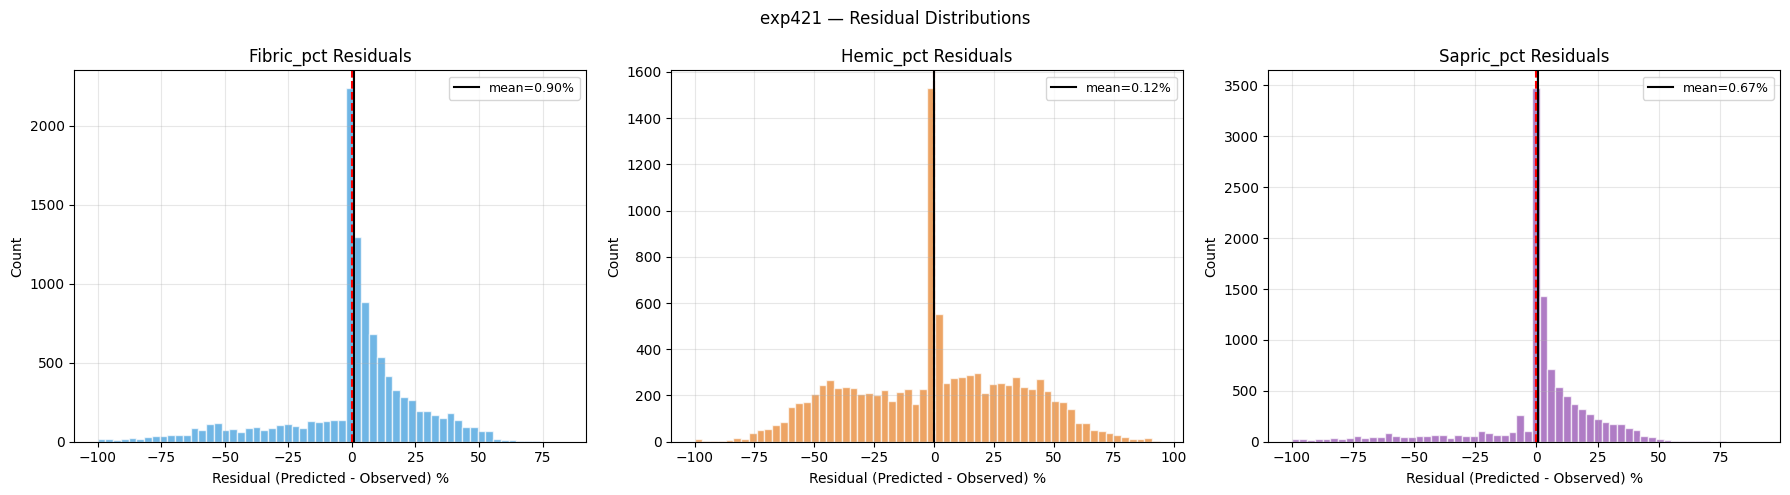

In [7]:
# Cell 7 — Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, target in zip(axes, TARGETS):
    residuals = oof_preds[target] - df[target].values
    ax.hist(residuals, bins=60, color=COLORS[target], alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', lw=1.5, linestyle='--')
    ax.axvline(residuals.mean(), color='black', lw=1.5, linestyle='-',
               label=f'mean={residuals.mean():.2f}%')
    ax.set_xlabel('Residual (Predicted - Observed) %')
    ax.set_ylabel('Count')
    ax.set_title(f'{target} Residuals')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('exp421 — Residual Distributions', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

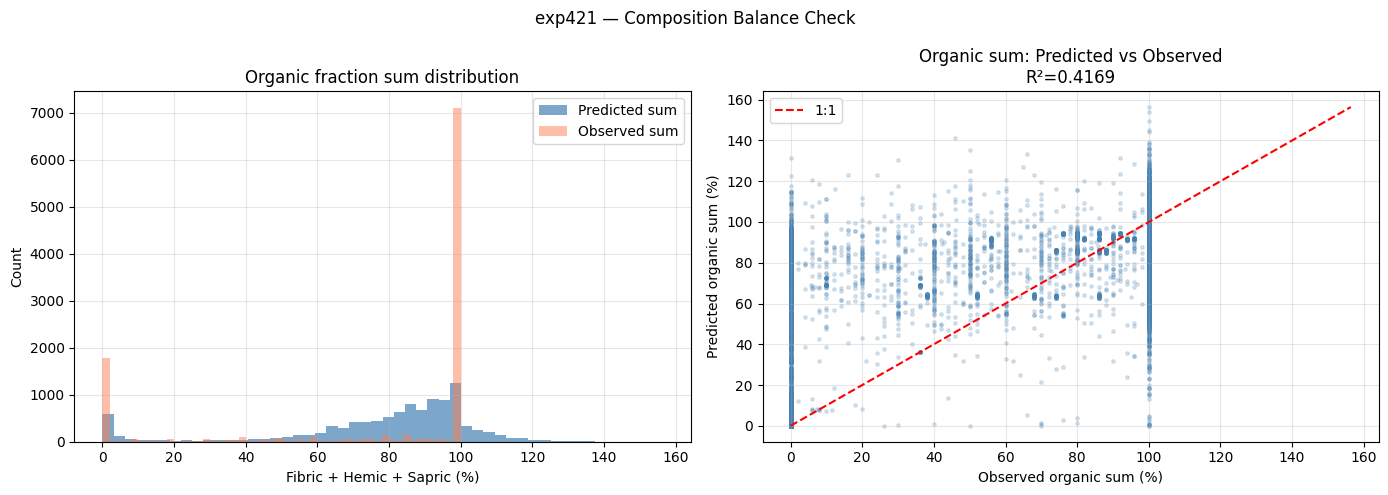

Predicted organic sum: mean=78.1%  std=28.2%
Observed organic sum:  mean=76.4%  std=38.9%


In [8]:
# Cell 8 — Composition balance check
pred_organic_sum = sum(oof_preds[t] for t in TARGETS)
obs_organic_sum  = df[TARGETS].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pred_organic_sum, bins=50, color='steelblue', alpha=0.7, label='Predicted sum')
axes[0].hist(obs_organic_sum,  bins=50, color='coral',     alpha=0.5, label='Observed sum')
axes[0].set_xlabel('Fibric + Hemic + Sapric (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Organic fraction sum distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(obs_organic_sum, pred_organic_sum, alpha=0.2, s=6, color='steelblue')
lim = max(obs_organic_sum.max(), pred_organic_sum.max())
axes[1].plot([0,lim],[0,lim],'r--',lw=1.5,label='1:1')
r2_sum = r2_score(obs_organic_sum, pred_organic_sum)
axes[1].set_xlabel('Observed organic sum (%)')
axes[1].set_ylabel('Predicted organic sum (%)')
axes[1].set_title(f'Organic sum: Predicted vs Observed\nR²={r2_sum:.4f}')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.suptitle('exp421 — Composition Balance Check', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'composition_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Predicted organic sum: mean={pred_organic_sum.mean():.1f}%  std={pred_organic_sum.std():.1f}%')
print(f'Observed organic sum:  mean={obs_organic_sum.mean():.1f}%  std={obs_organic_sum.std():.1f}%')

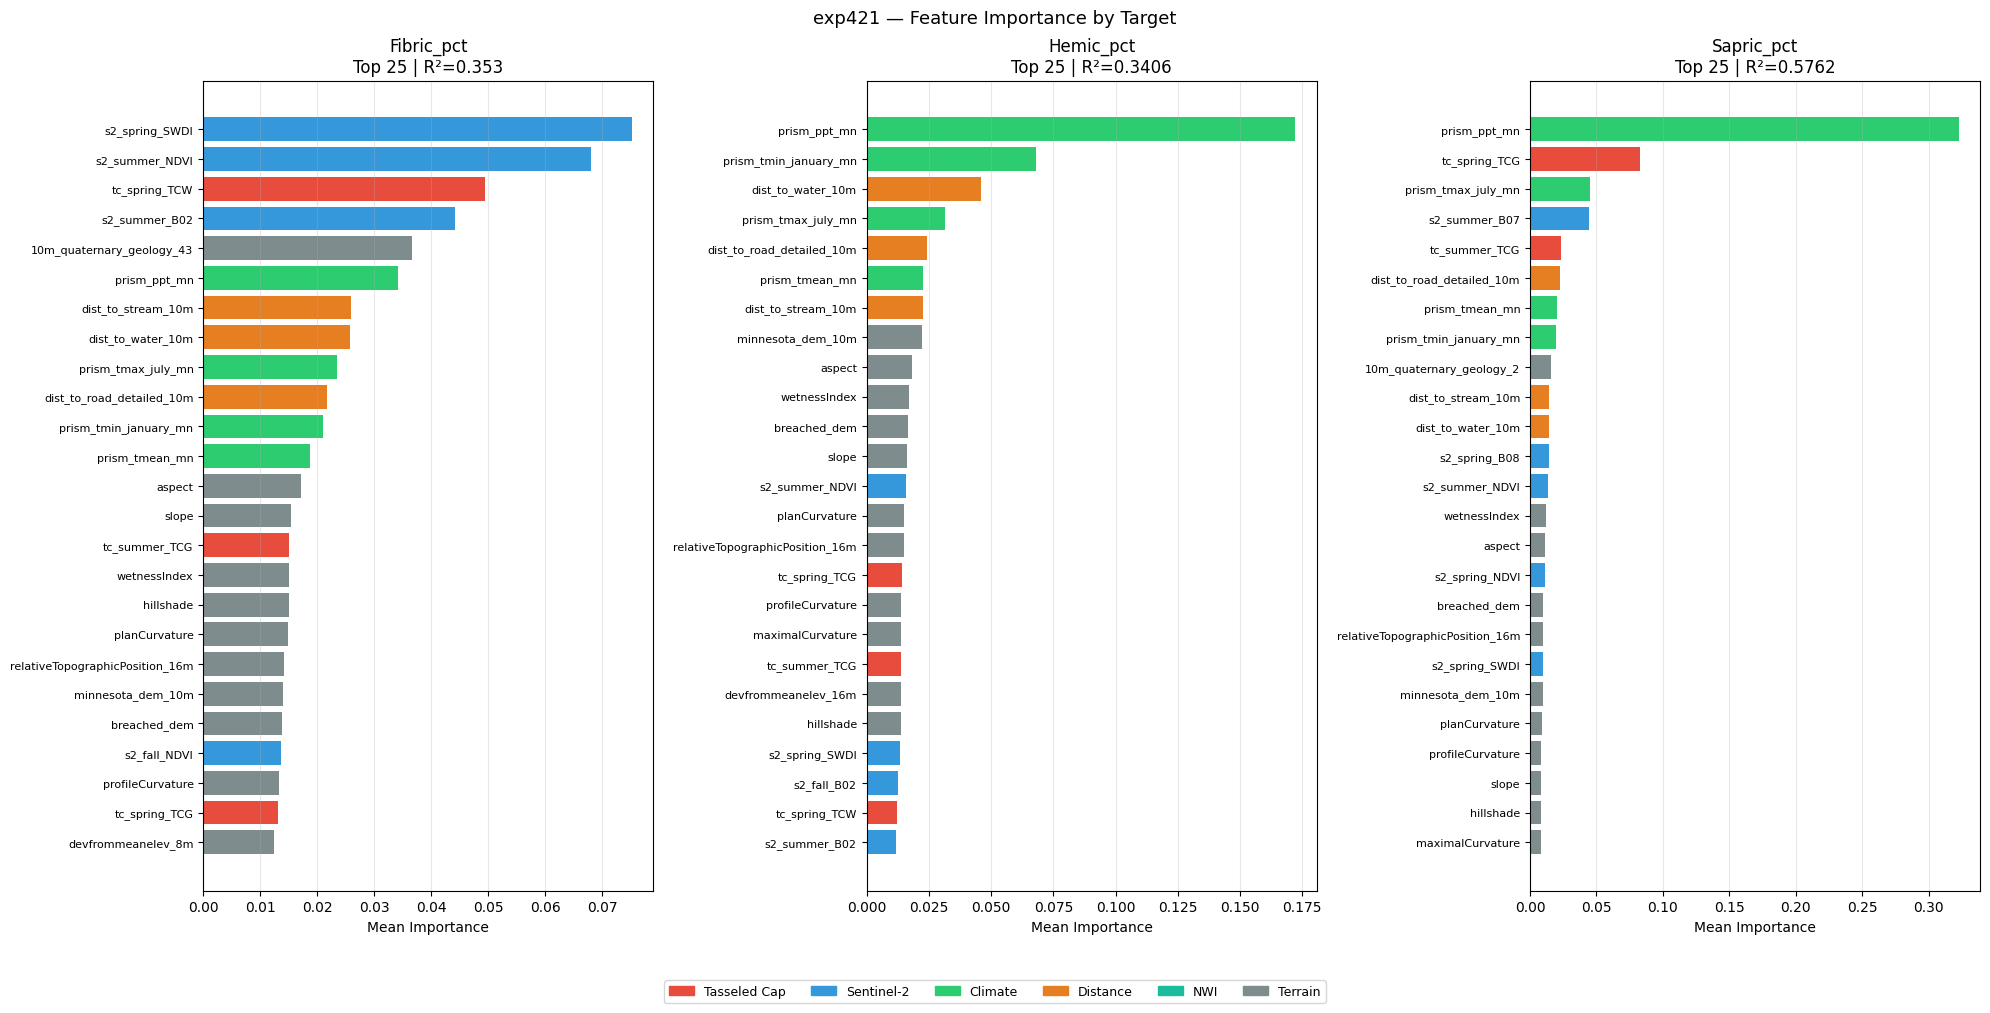

In [9]:
# Cell 9 — Feature importance
def get_color(feat):
    if feat.startswith('tc_'):    return '#e74c3c'
    if feat.startswith('s2_'):    return '#3498db'
    if feat.startswith('prism_'): return '#2ecc71'
    if feat.startswith('dist_'):  return '#e67e22'
    if feat.startswith('mn_nwi'): return '#1abc9c'
    return '#7f8c8d'

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
for ax, target in zip(axes, TARGETS):
    imp = np.mean([m.feature_importances_ for m in models[target]], axis=0)
    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': imp}) \
               .sort_values('importance', ascending=False).head(25)
    clrs = [get_color(f) for f in imp_df['feature']]
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=clrs[::-1])
    ax.set_title(f"{target}\nTop 25 | R²={meta['results'][target]['mean_r2']}")
    ax.set_xlabel('Mean Importance')
    ax.grid(alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=8)
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Tasseled Cap'),
    mpatches.Patch(color='#3498db', label='Sentinel-2'),
    mpatches.Patch(color='#2ecc71', label='Climate'),
    mpatches.Patch(color='#e67e22', label='Distance'),
    mpatches.Patch(color='#1abc9c', label='NWI'),
    mpatches.Patch(color='#7f8c8d', label='Terrain'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5,-0.02))
plt.suptitle('exp421 — Feature Importance by Target', fontsize=13)
plt.tight_layout(rect=[0,0.04,1,1])
plt.savefig(os.path.join(RES_DIR,'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

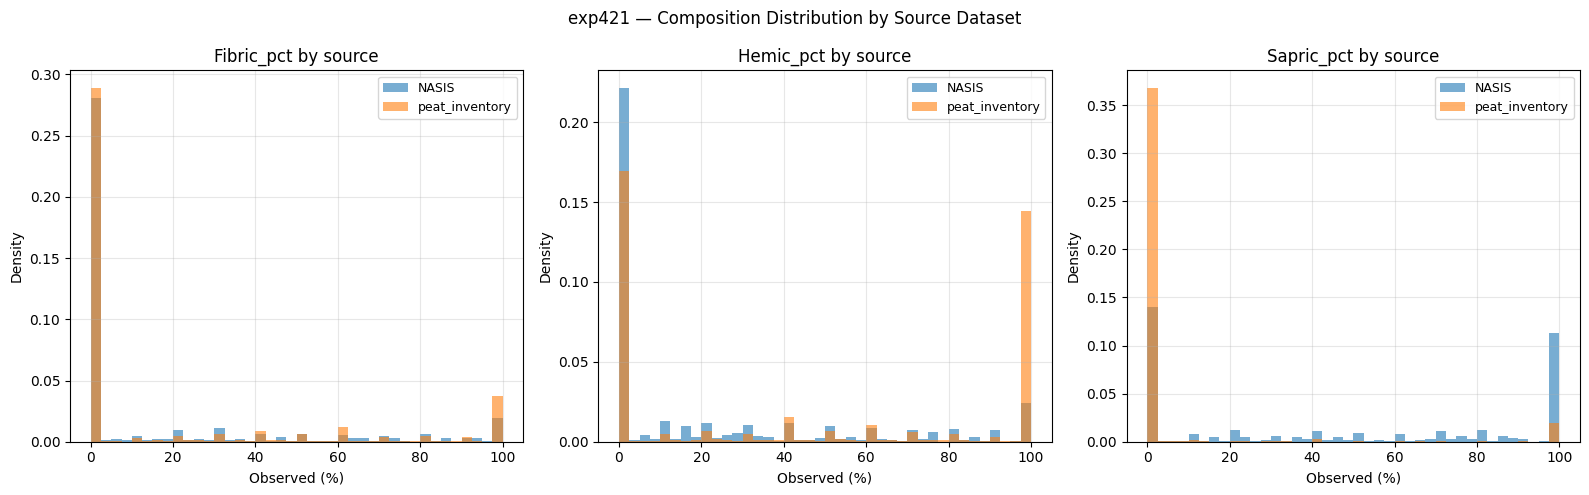

Source breakdown in masked training set:
source
peat_inventory    6777
NASIS             3902

Mean composition by source:
                Fibric_pct  Hemic_pct  Sapric_pct  Mineral_pct  Unknown_pct
source                                                                     
NASIS                 16.3       22.4        46.9         11.0          3.4
peat_inventory        18.6       46.4         6.1         24.3          4.6


In [10]:
# Cell 10 — Composition distribution by source
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target in zip(axes, TARGETS):
    for src, grp in df.groupby('source'):
        ax.hist(grp[target], bins=40, alpha=0.6, label=src, density=True)
    ax.set_xlabel('Observed (%)')
    ax.set_ylabel('Density')
    ax.set_title(f'{target} by source')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('exp421 — Composition Distribution by Source Dataset', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR,'composition_by_source.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Source breakdown in masked training set:')
print(df['source'].value_counts().to_string())
print()
print('Mean composition by source:')
print(df.groupby('source')[TARGETS + ['Mineral_pct','Unknown_pct']].mean().round(1).to_string())

In [11]:
# Cell 11 — MODEL_CATALOG check
catalog = pd.read_csv(CATALOG)
row = catalog[catalog['exp_id'] == 'exp421']
if len(row) == 0:
    print('WARNING: exp421 not in MODEL_CATALOG')
else:
    print('exp421 in MODEL_CATALOG:')
    print(row[['exp_id','exp_name','n_samples','n_features',
               'mean_r2','mean_rmse','date','notes']].T.to_string())

exp421 in MODEL_CATALOG:
                                                                                                                                                       30
exp_id                                                                                                                                             exp421
exp_name                                                                         Organic Composition Regression - Fibric/Hemic/Sapric - exp410>=0.33 mask
n_samples                                                                                                                                           10679
n_features                                                                                                                                            125
mean_r2                                                                                                                                            0.4233
mean_rmse                                          